## <center> Hyperspectral Imaging Spectral Profile of Instant Coffee</Ceter>

In [3]:
# Load packages 
import os 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# set the working directory 
os.chdir('C:\\Users\\abc\\OneDrive - UGent\\Documenten\\Derick Malavi_PhD Docs_UGent\\Manuscript 4_Coffee\\Instant_Coffee\\Exploratory_Data_Analysis')

In [5]:
# Read_data
instant_raw = pd.read_excel('instant_coffee_raw.xlsx')
instant_msc_sg_2d = pd.read_excel('coffee_instant_msc_sg_2d.xlsx')
instant_snv_sg_1d = pd.read_excel('coffee_instant_snv_sg_1d.xlsx')

In [6]:
# Check the shape of the data
print(instant_raw.shape)
print(instant_msc_sg_2d.shape)

(1476, 229)
(1476, 229)


In [7]:
# Check the first few rows 
instant_raw.head(5)

,sample_name,binary_class,three_class,cal_val,perc_adulter,935.609985,939.059998,942.52002,945.97998,949.429993,...,1688.02002,1691.589966,1695.170044,1698.75,1702.329956,1705.910034,1709.48999,1713.069946,1716.650024,1720.22998
0,Arabica_10,pure_arabica,pure_arabica,1,0,0.530853,0.533619,0.561054,0.582093,0.596901,...,0.540360,0.536110,0.532238,0.528059,0.525007,0.521218,0.516975,0.511108,0.504414,0.496085
1,Arabica_10,pure_arabica,pure_arabica,1,0,0.533290,0.535996,0.563077,0.583506,0.597973,...,0.539968,0.535841,0.532169,0.528426,0.525502,0.522217,0.517889,0.511993,0.505306,0.497512
2,Arabica_10,pure_arabica,pure_arabica,1,0,0.531486,0.534291,0.561071,0.581973,0.596549,...,0.545723,0.541324,0.537376,0.532705,0.529344,0.525174,0.520571,0.514255,0.507121,0.499195
3,Arabica_11,pure_arabica,pure_arabica,1,0,0.563388,0.566406,0.596824,0.619869,0.635869,...,0.541186,0.537560,0.534226,0.530944,0.528720,0.525882,0.521746,0.516036,0.510318,0.502815
4,Arabica_11,pure_arabica,pure_arabica,1,0,0.560974,0.563901,0.593892,0.617615,0.633946,...,0.540318,0.536781,0.533500,0.530279,0.527773,0.524809,0.520953,0.515072,0.509542,0.502504


In [8]:
instant_msc_sg_2d.head(5)

,sample_name,binary_class,three_class,cal_val,perc_adulter,935.609985,939.059998,942.52002,945.97998,949.429993,...,1688.02002,1691.589966,1695.170044,1698.75,1702.329956,1705.910034,1709.48999,1713.069946,1716.650024,1720.22998
0,Arabica_10,pure_arabica,pure_arabica,1,0,-0.001552,-0.001552,-0.001552,-0.001552,-0.001552,...,0.000132,-1.033667e-07,-0.000131,-0.000262,-0.000262,-0.000262,-0.000262,-0.000262,-0.000262,-0.000262
1,Arabica_10,pure_arabica,pure_arabica,1,0,-0.001511,-0.001511,-0.001511,-0.001511,-0.001511,...,0.000197,4.488908e-05,-0.000110,-0.000250,-0.000250,-0.000250,-0.000250,-0.000250,-0.000250,-0.000250
2,Arabica_10,pure_arabica,pure_arabica,1,0,-0.001539,-0.001539,-0.001539,-0.001539,-0.001539,...,0.000071,-4.759905e-05,-0.000168,-0.000277,-0.000277,-0.000277,-0.000277,-0.000277,-0.000277,-0.000277
3,Arabica_11,pure_arabica,pure_arabica,1,0,-0.001711,-0.001711,-0.001711,-0.001711,-0.001711,...,0.000181,3.119187e-05,-0.000106,-0.000236,-0.000236,-0.000236,-0.000236,-0.000236,-0.000236,-0.000236
4,Arabica_11,pure_arabica,pure_arabica,1,0,-0.001729,-0.001729,-0.001729,-0.001729,-0.001729,...,0.000183,2.837233e-05,-0.000109,-0.000232,-0.000232,-0.000232,-0.000232,-0.000232,-0.000232,-0.000232


In [9]:
# Select the X columns
X_raw = instant_raw.iloc[:,5:230]
X_msc_sg = instant_msc_sg_2d.iloc[:,5:230]
X_snv_sg = instant_snv_sg_1d.iloc[:,5:230]

In [10]:
X_raw.head(2)

,935.609985,939.059998,942.520020,945.979980,949.429993,952.890015,956.349976,959.809998,963.270020,966.729980,...,1688.020020,1691.589966,1695.170044,1698.750000,1702.329956,1705.910034,1709.489990,1713.069946,1716.650024,1720.229980
0,0.530853,0.533619,0.561054,0.582093,0.596901,0.607297,0.614599,0.619740,0.624382,0.628434,...,0.540360,0.536110,0.532238,0.528059,0.525007,0.521218,0.516975,0.511108,0.504414,0.496085
1,0.533290,0.535996,0.563077,0.583506,0.597973,0.608417,0.615659,0.620909,0.625485,0.629532,...,0.539968,0.535841,0.532169,0.528426,0.525502,0.522217,0.517889,0.511993,0.505306,0.497512


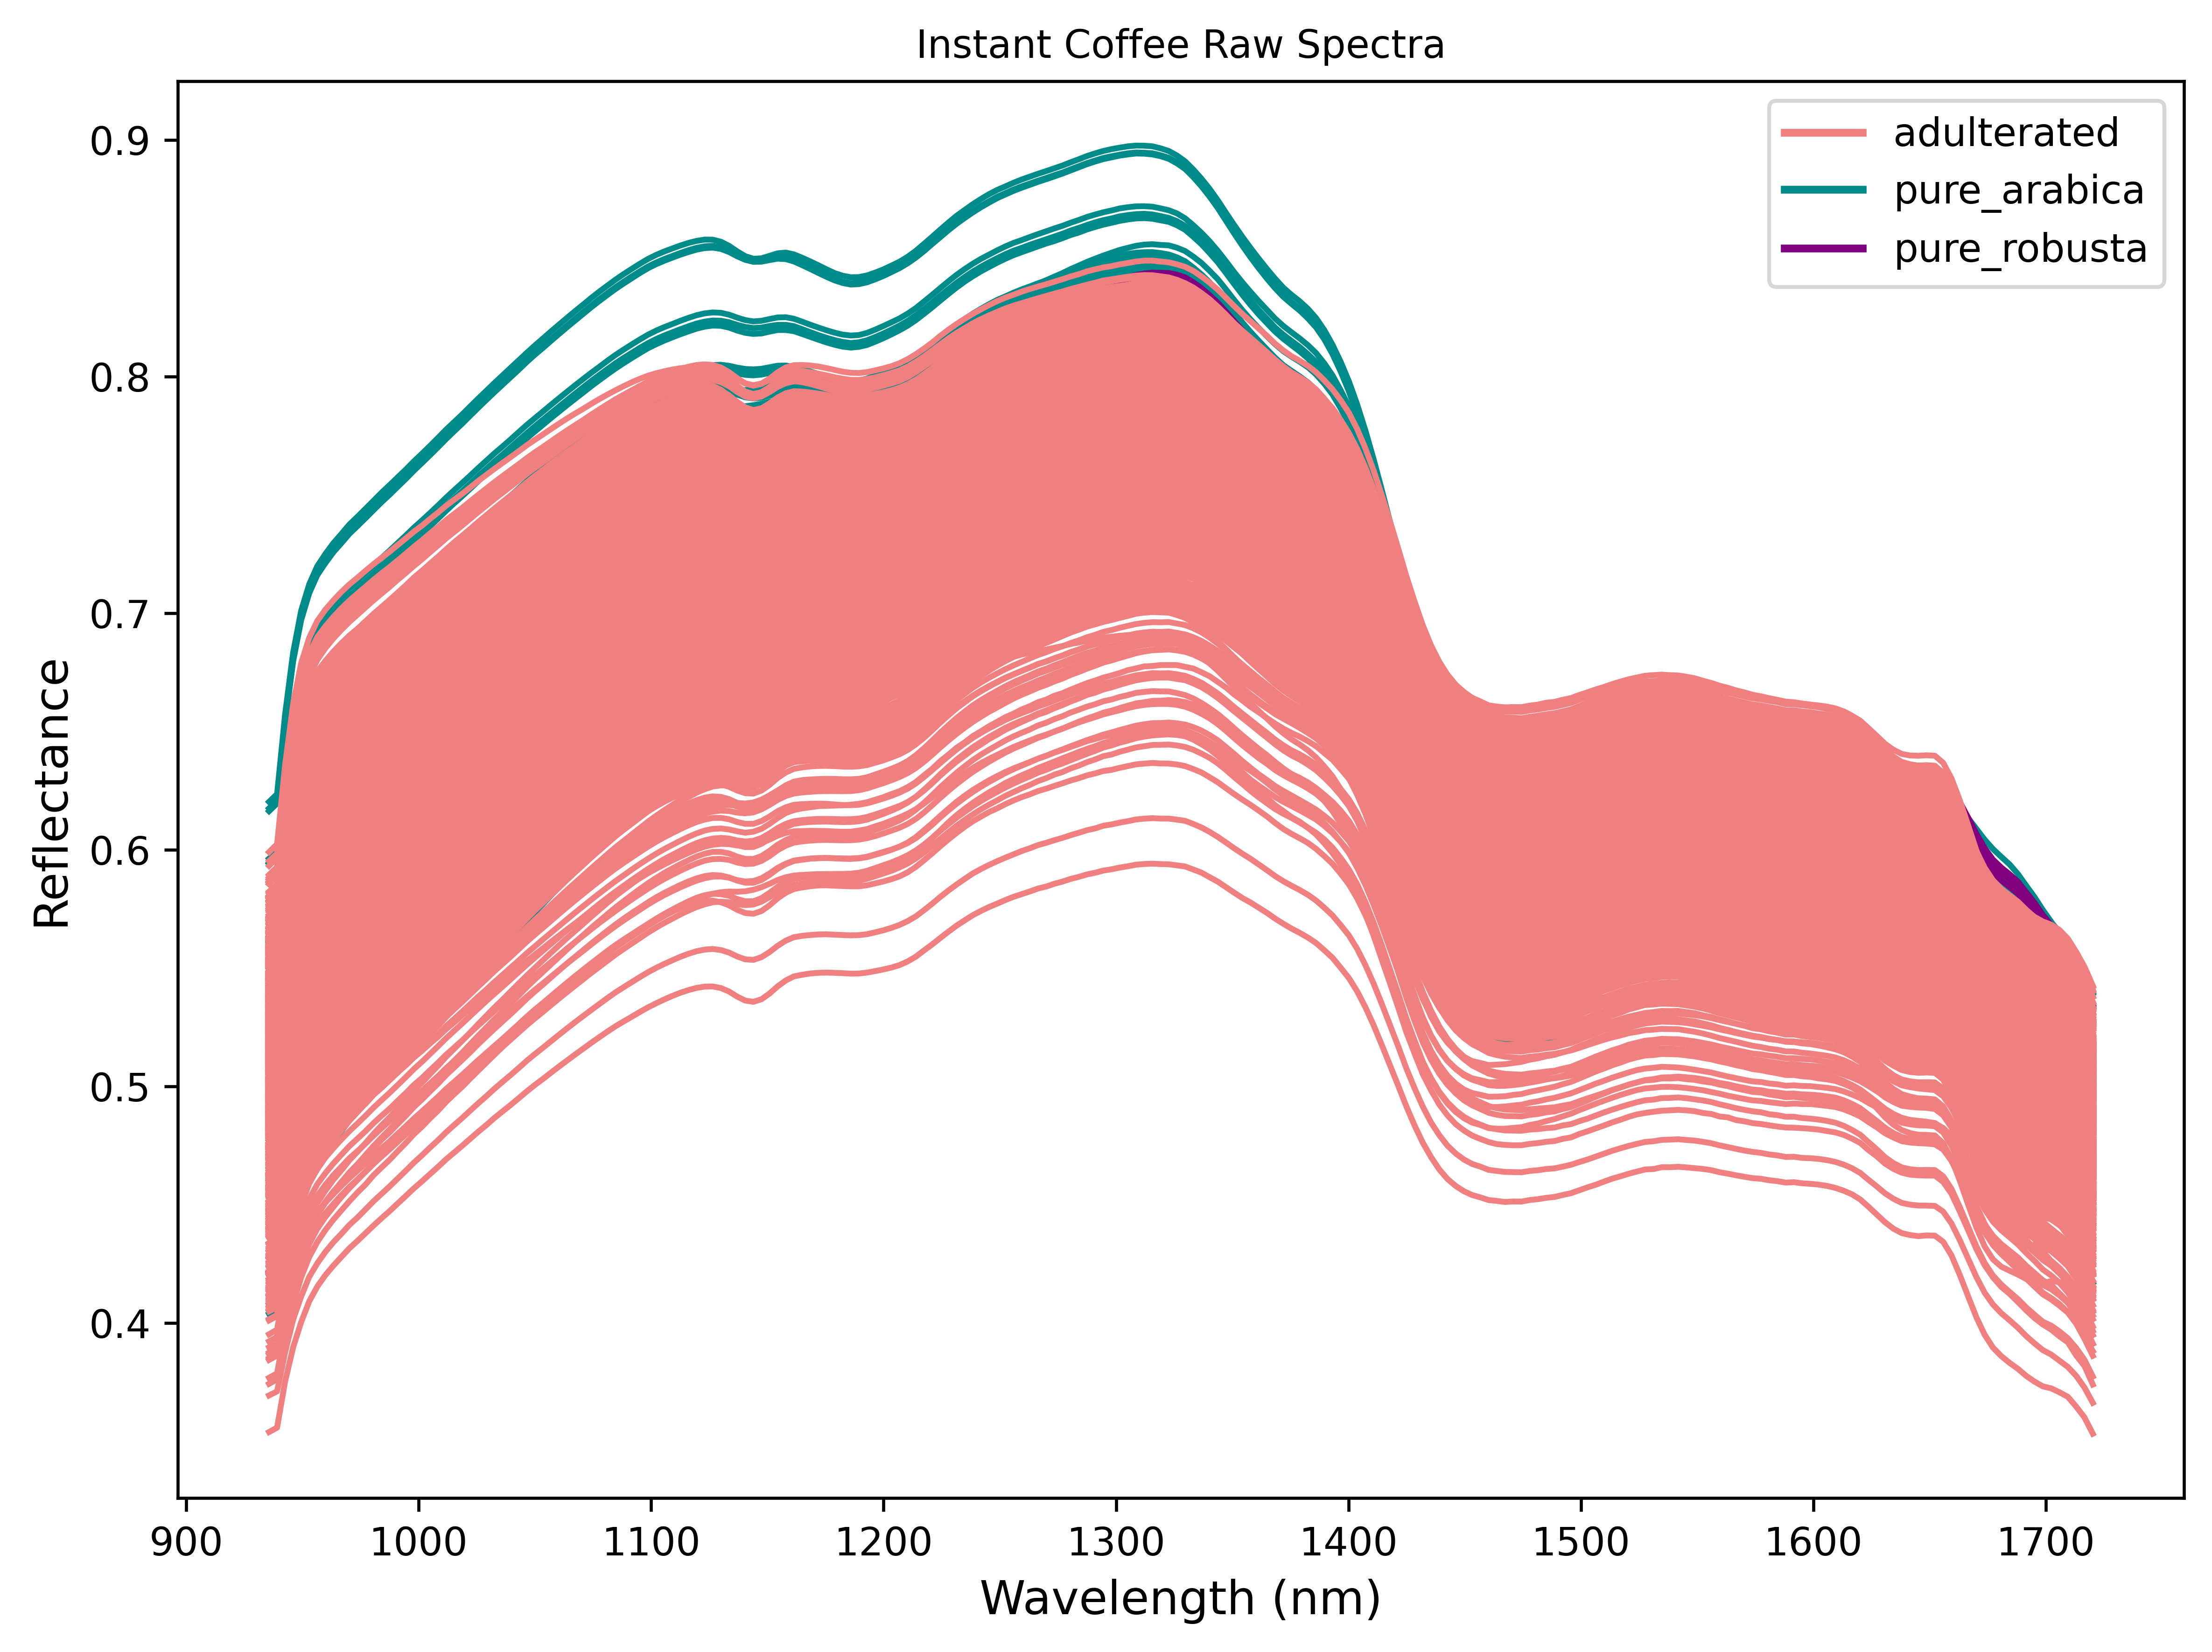

In [11]:
# Raw spectra
# Define the three classes
three_class = instant_raw['three_class']

# Extract the spectral wavelengths 
wavelengths = X_raw.columns.astype(float)

# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_raw.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Instant Coffee Raw Spectra', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("instant_Coffee_Spectra.png", dpi=600, bbox_inches="tight", format="png")

# Show the plot
plt.show()

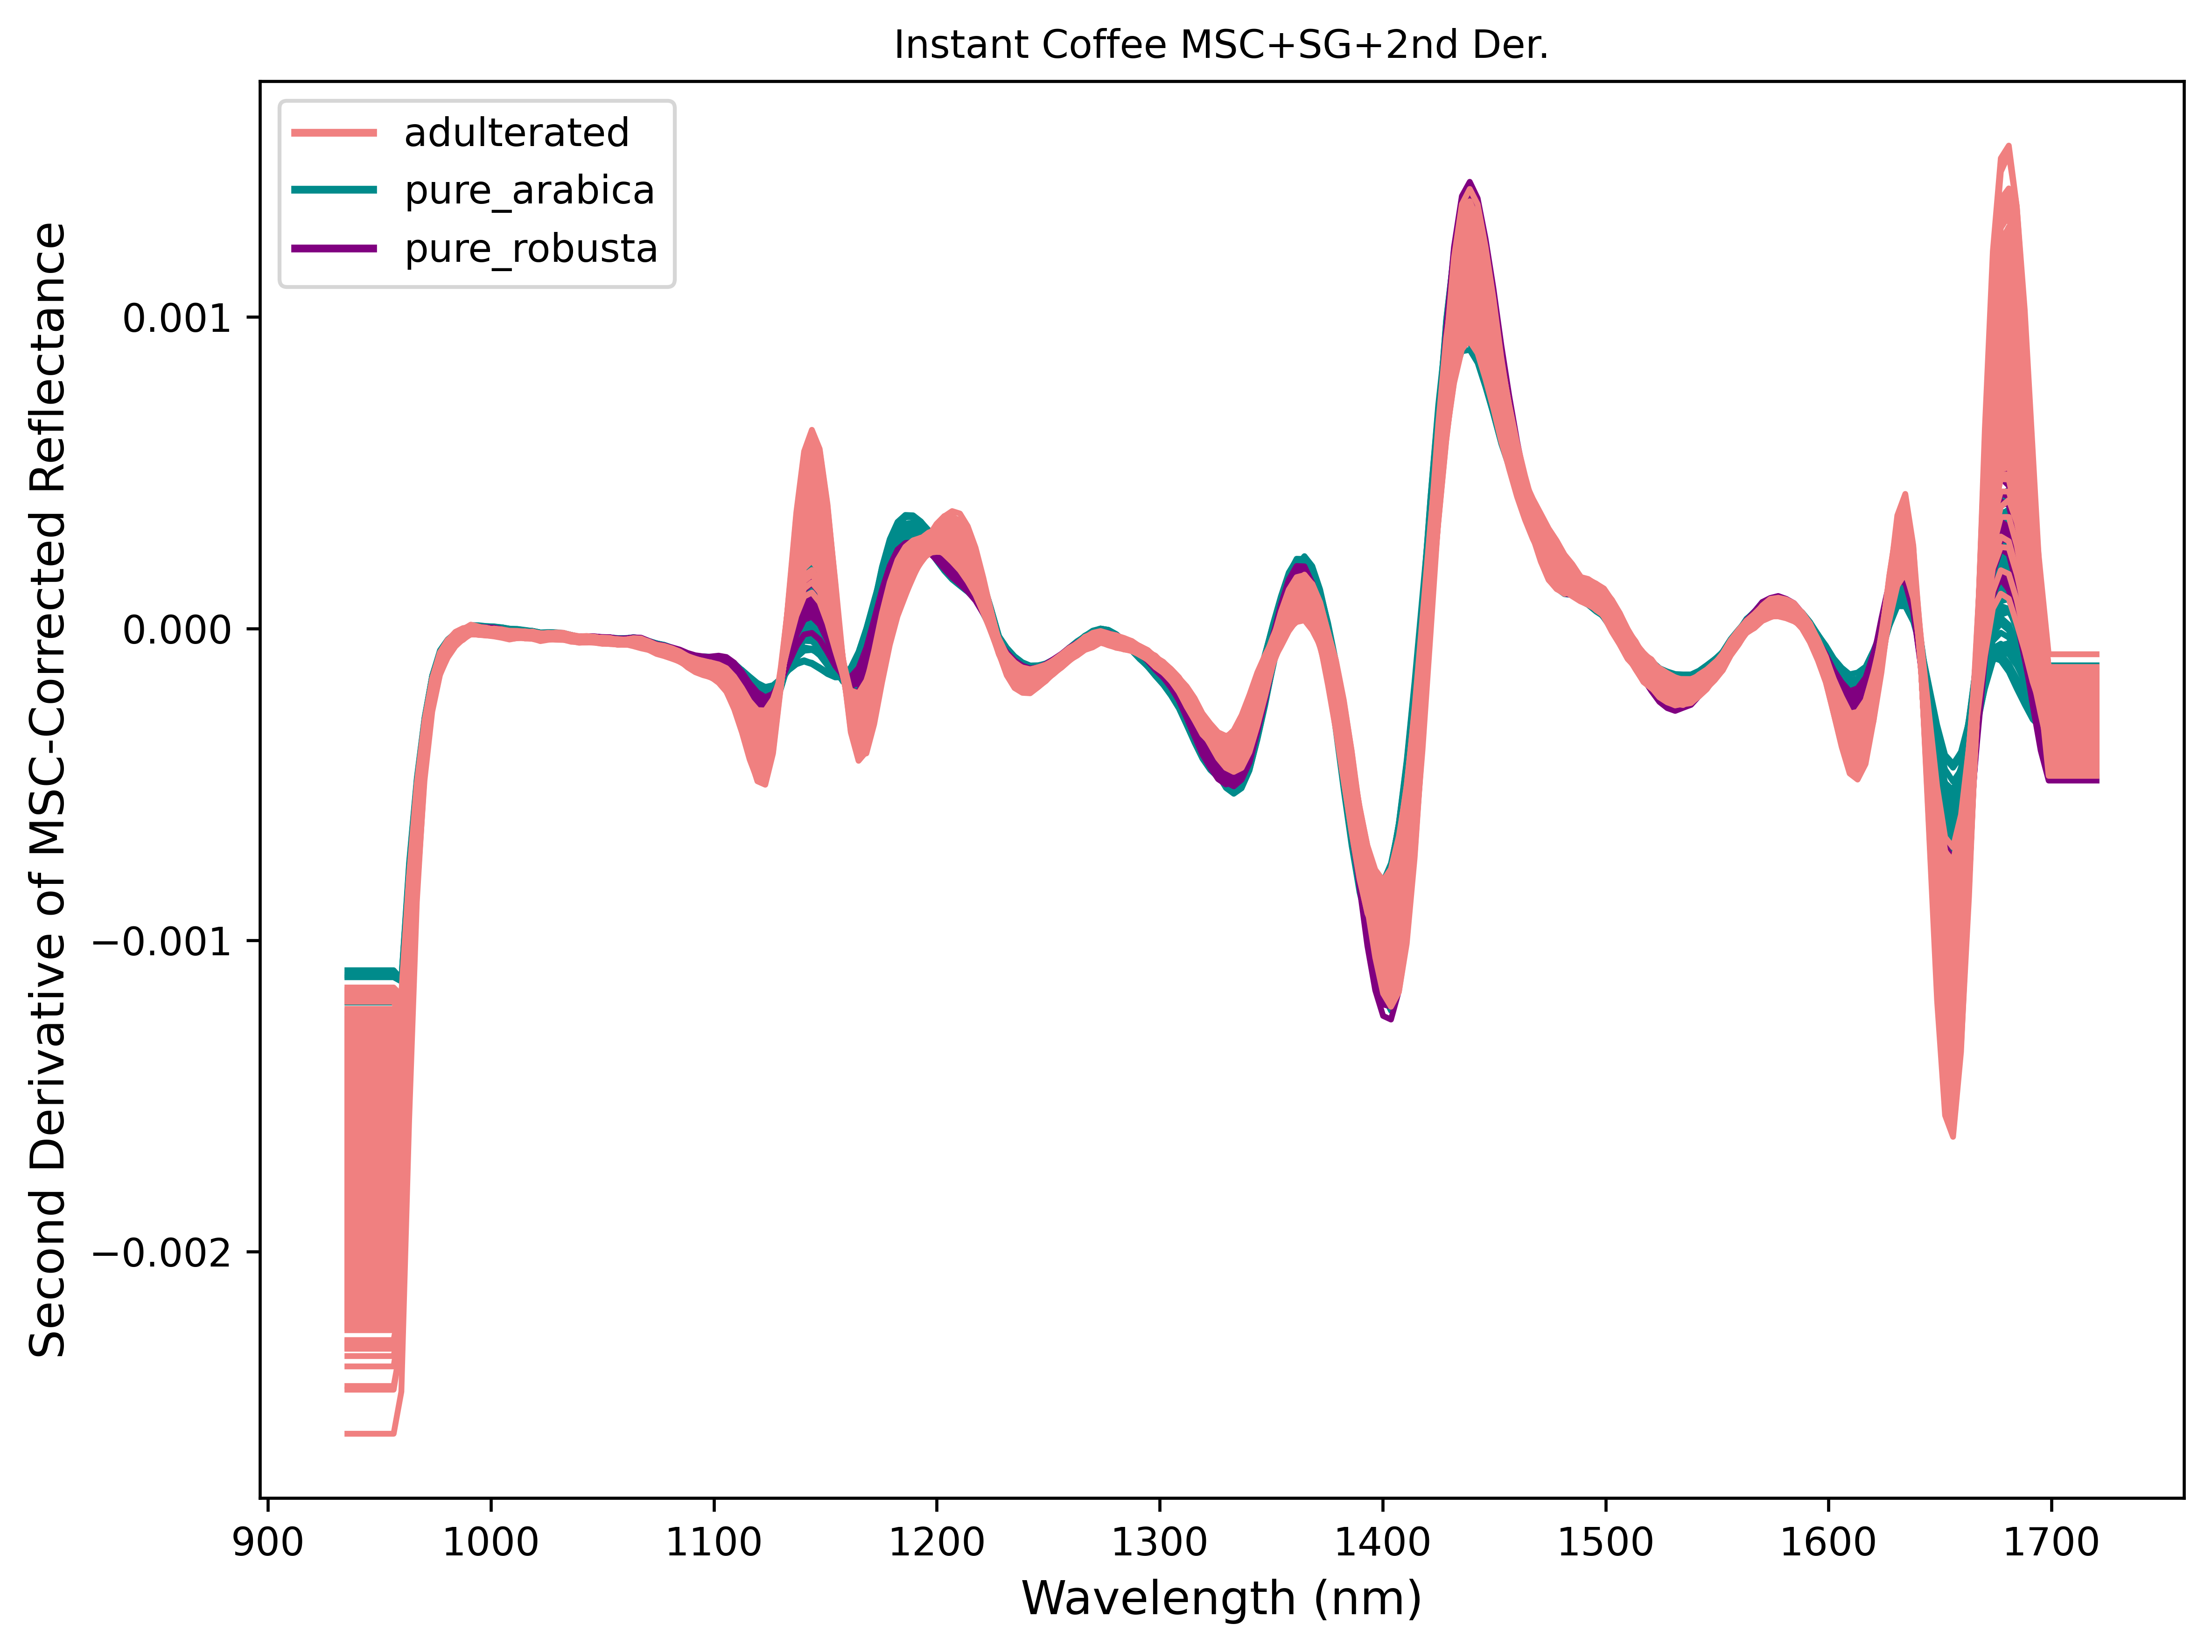

In [12]:
# Extract the spectral wavelengths 
wavelengths = X_msc_sg.columns.astype(float)

# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_msc_sg.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Instant Coffee MSC+SG+2nd Der.', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Second Derivative of MSC-Corrected Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper left')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("instant_Coffee_Spectra_MSC_SG_2D.png", dpi=600, bbox_inches="tight", format="png")

# Show the plot
plt.show()

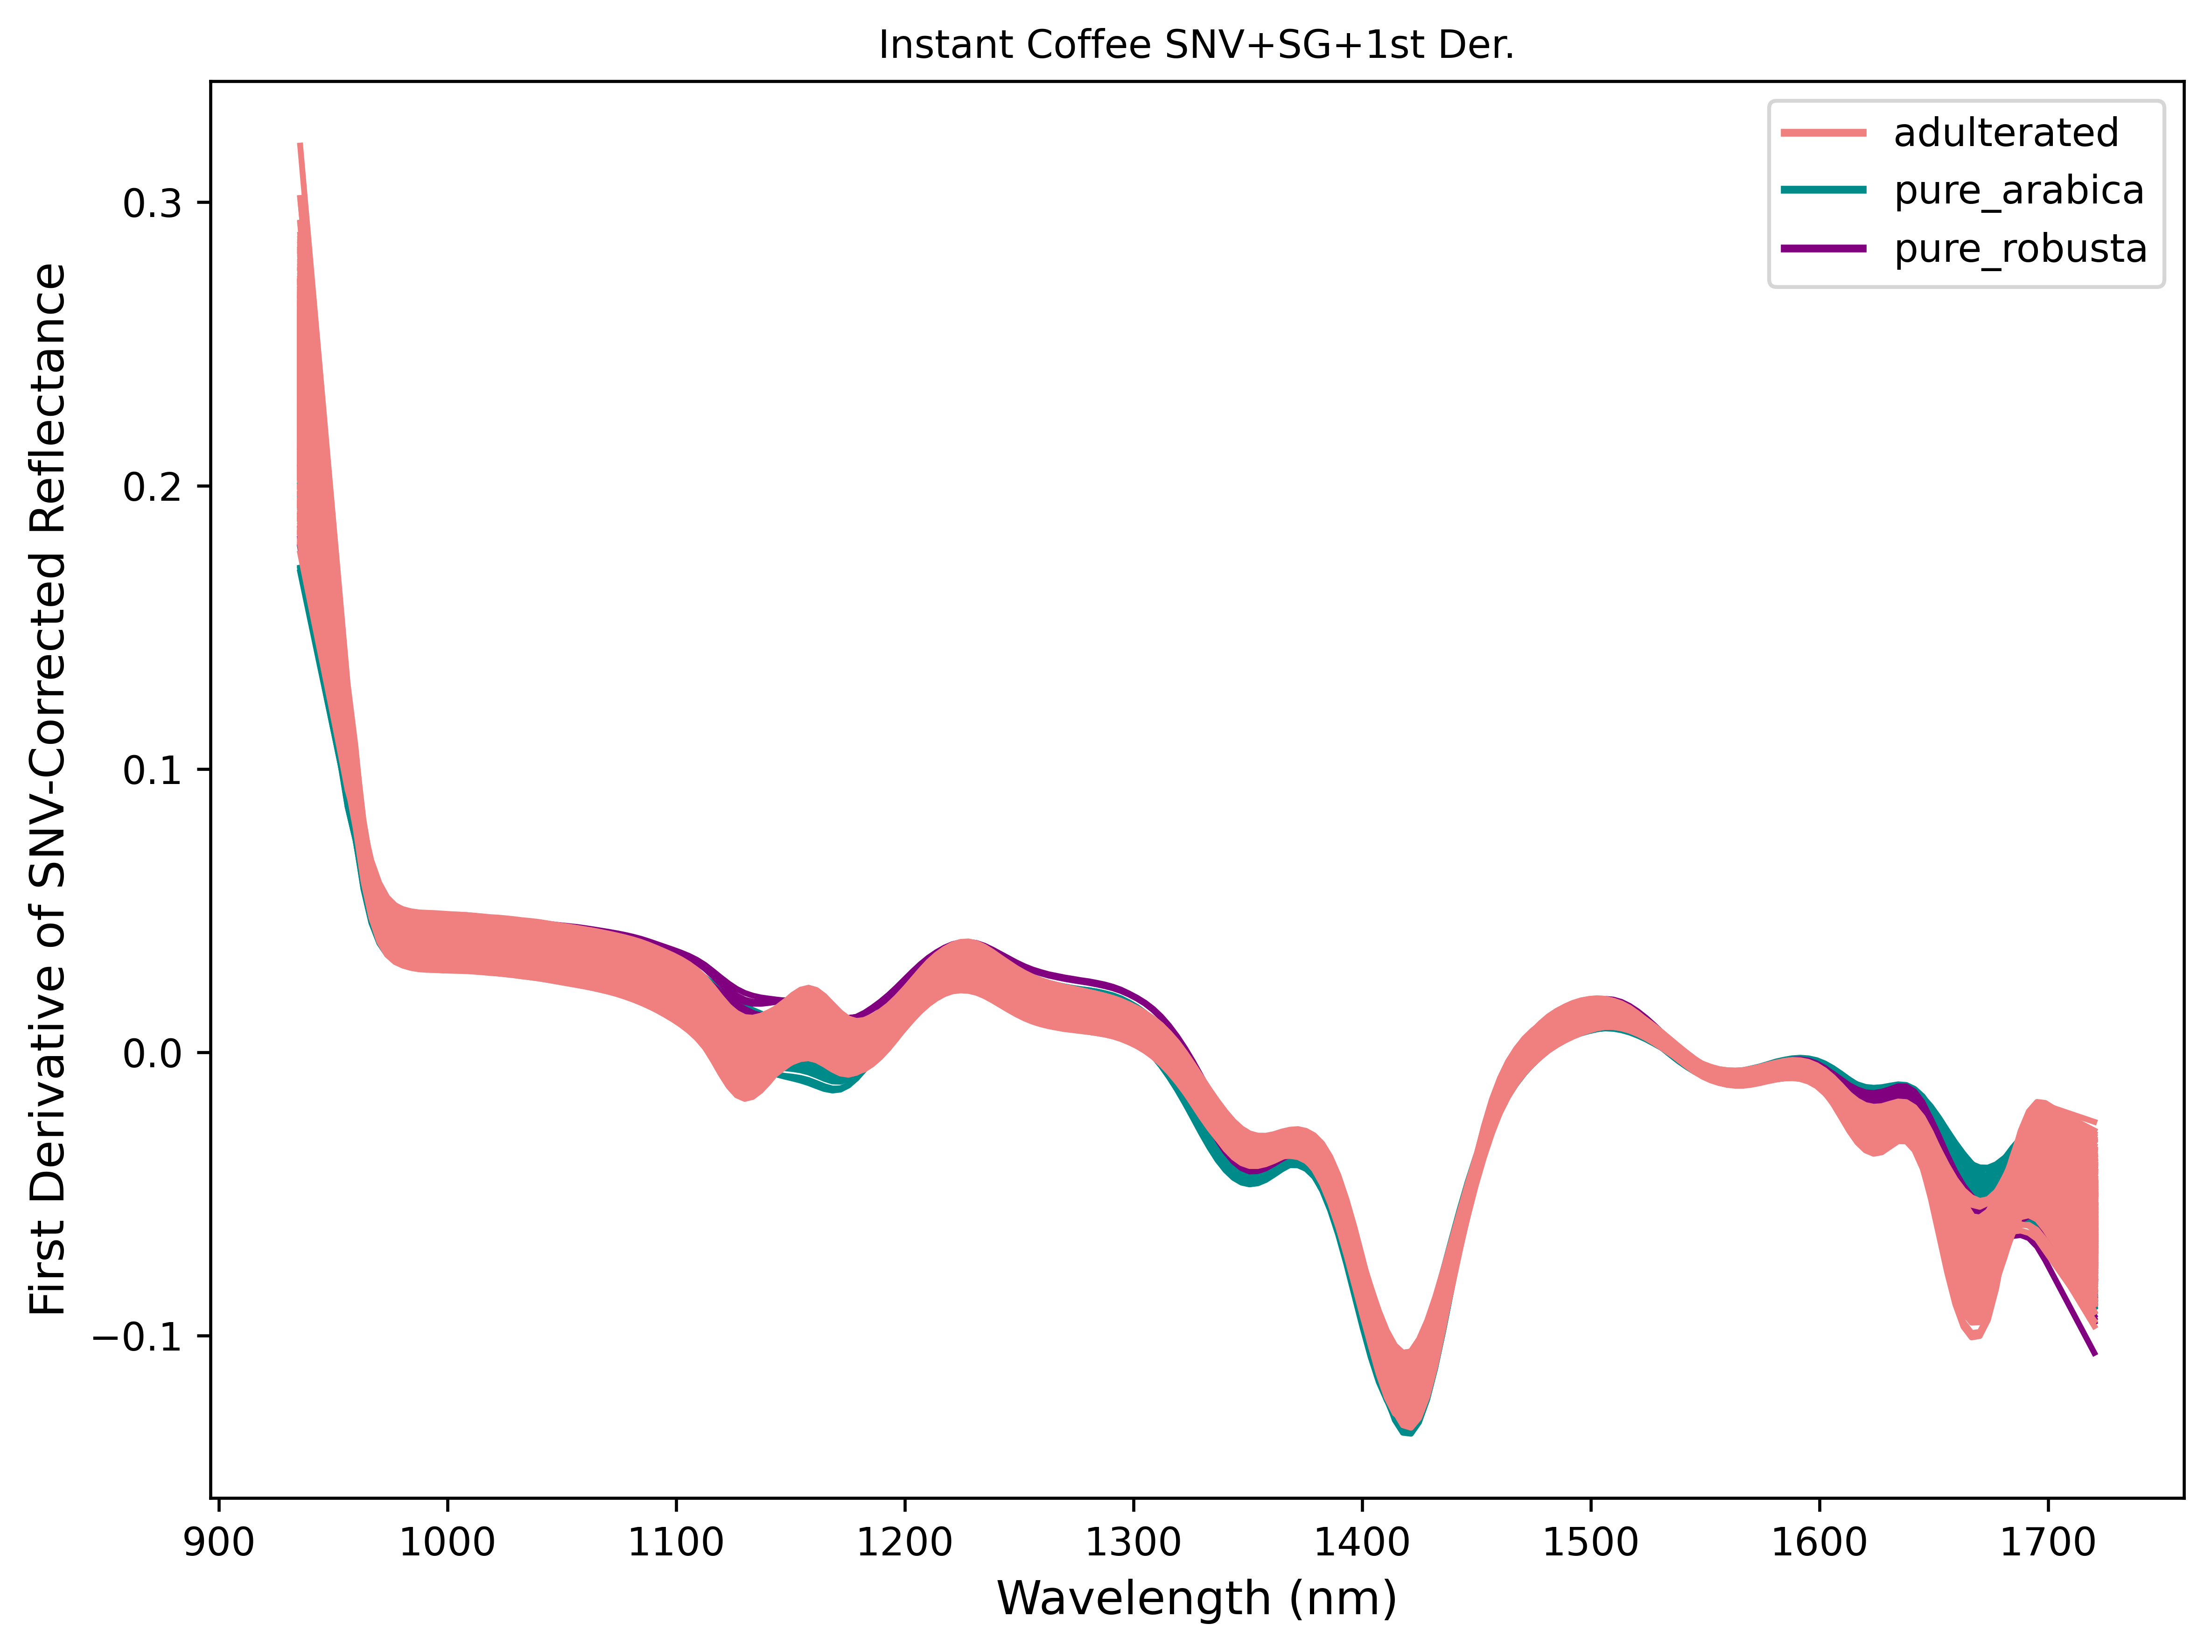

In [13]:
# SNV and Derivative Data
# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_snv_sg.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Instant Coffee SNV+SG+1st Der.', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('First Derivative of SNV-Corrected Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("instant_Coffee_Spectra_SNV_SG_1D.png", dpi=600, bbox_inches="tight", format="png")

# Show the plot
plt.show()